In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('Housing.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


sqft_living: 188.51
sqft_lot: -0.26
sqft_above: 86.26
sqft_basement: 102.24
intercept: -32056.13
Training Score (R^2): 0.48875728783663897
Testing Score (R^2): 0.5125945286671987


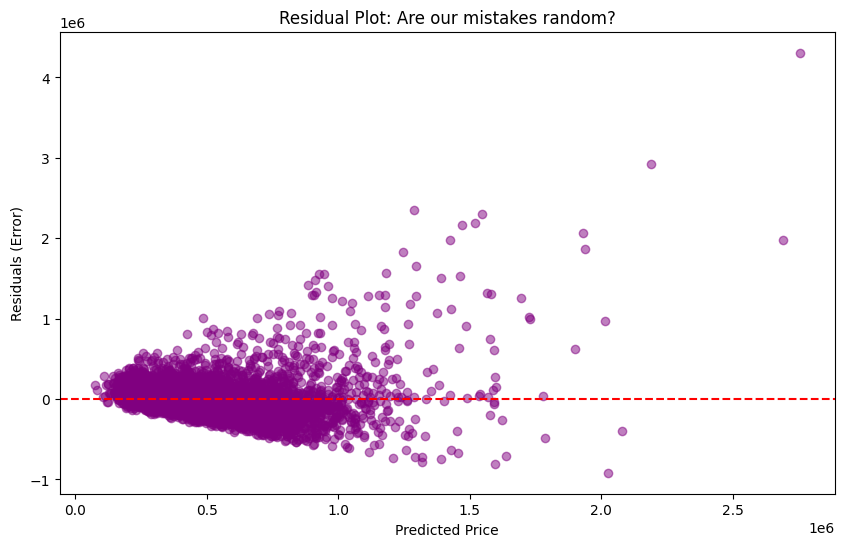

In [4]:

features = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement'] # I'm trying to capture all area-related X-coordinate data since that is (i believe) the most likely to increase price
X = df[features]  # This is now a 2D table, not a single line 
y = df['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)



model = LinearRegression()
model.fit(X_train, y_train)

for feature, weight in zip(features, model.coef_):
    print(f"{feature}: {weight:.2f}")

print(f"intercept: {model.intercept_:.2f}")

print("Training Score (R^2):", model.score(X_train, y_train))
print("Testing Score (R^2):", model.score(X_test, y_test))

# Here our training and testing score are identical (R^2 = 0.5). This is great news because it tells us that our model can act as reliably with new data as it did with the training. We are neither underfitting nor overfitting.
# This is still not an optimal solution as our model is still too simple (high bias)\

y_pred = model.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--') # The "Perfect" line
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Error)')
plt.title('Residual Plot: Are our mistakes random?')
plt.show()

sqft_living: 68.4682
sqft_lot: 0.6046
sqft_above: -4.1241
sqft_basement: 72.5923
sqft_living^2: 0.0230
sqft_living sqft_lot: -0.0006
sqft_living sqft_above: 0.0402
sqft_living sqft_basement: -0.0172
sqft_lot^2: 0.0000
sqft_lot sqft_above: 0.0002
sqft_lot sqft_basement: -0.0008
sqft_above^2: -0.0238
sqft_above sqft_basement: 0.0641
sqft_basement^2: -0.0813
193426.780075029


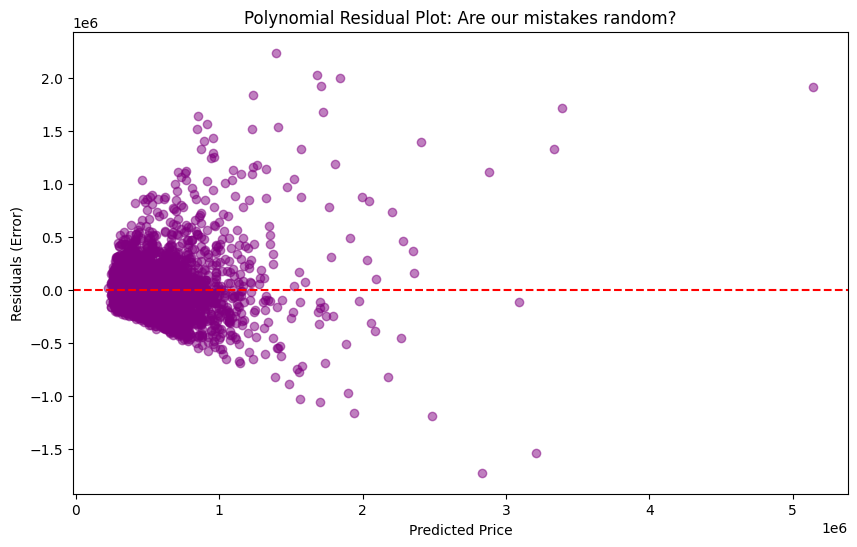

In [5]:
# Now we will try polynomial features (As per Gemini)

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False) # degree=2 means we will create 2nd degree polynomial features
X_poly = poly.fit_transform(X)

X_train_poly = poly.fit_transform(X_train) # Transforms our training data to degree 2
X_test_poly = poly.transform(X_test) # Transforms our testing data to degree 2

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

poly_features = poly.get_feature_names_out(features)
for name, weight in zip(poly_features, poly_model.coef_): # Prints weights for all new features
    print(f"{name}: {weight:.4f}")
print(poly_model.intercept_)

y_pred_poly = poly_model.predict(X_test_poly)
residuals = y_test - y_pred_poly
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_poly, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--') # The "Perfect" line
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Error)')
plt.title('Polynomial Residual Plot: Are our mistakes random?')
plt.show()

# Not a huge difference

In [8]:
# Lets use traditionla linear regression with gradient descent

import numpy as np

class MyLinearRegression:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = 0
        self.cost_history = []

    def fit(self, X, y):
        # m = number of samples, n = number of features
        m, n = X.shape
        
        # 1. Initialize weights as zeros
        self.weights = np.zeros(n)
        self.bias = 0

        # 2. Gradient Descent Loop
        for i in range(self.iterations):
            # Vectorized Prediction (y_hat)
            y_hat = np.dot(X, self.weights) + self.bias
            
            # Calculate Error
            error = y_hat - y
            
            # Calculate Cost (MSE)
            cost = (1 / (2 * m)) * np.sum(np.square(error))
            self.cost_history.append(cost)

            # 3. Calculate Gradients (Vectorized)
            # dw is the derivative of cost with respect to weights
            dw = (1 / m) * np.dot(X.T, error)
            db = (1 / m) * np.sum(error)

            # 4. Update Weights and Bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias



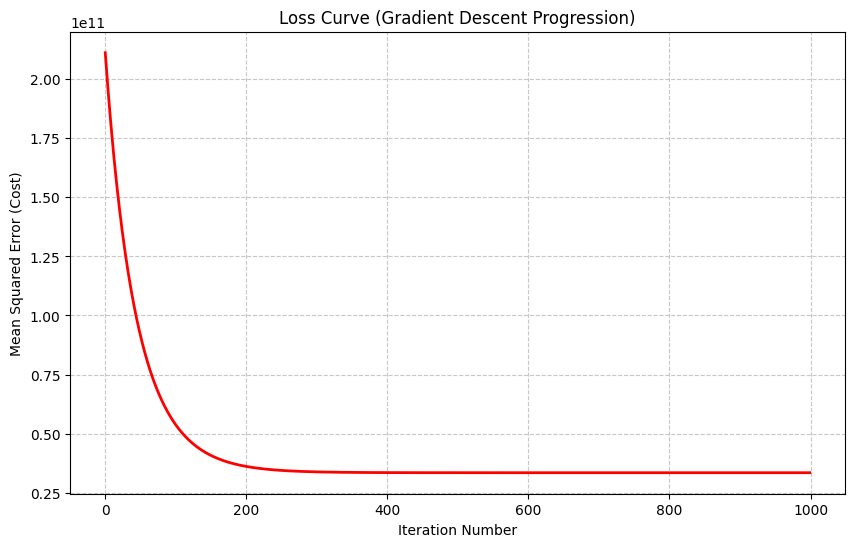

In [ ]:
# Time to use this 'from-scratch' model


# First we will scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Now lets run the model

my_model = MyLinearRegression(learning_rate=0.01, iterations=1000)
my_model.fit(X_train_scaled, y_train)
plt.figure(figsize=(10, 6))
plt.plot(my_model.cost_history, color='red', linewidth=2)

# 2. Add labels
plt.title("Loss Curve (Gradient Descent Progression)")
plt.xlabel("Iteration Number")
plt.ylabel("Mean Squared Error (Cost)")
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()



In [ ]:
# Now we will compare how scikit-learn differs from our attempt

from sklearn.linear_model import LinearRegression

# 1. Train Scikit-Learn on the SAME scaled data
sklearn_model = LinearRegression()
sklearn_model.fit(X_train_scaled, y_train) 

# 2. Compare Weights (Coefficients)
print("--- WEIGHT COMPARISON ---")
for i, name in enumerate(features):
    print(f"{name}:")
    print(f"  Scratch: {my_model.weights[i]:.4f}")
    print(f"  Sklearn: {sklearn_model.coef_[i]:.4f}")
    print("-" * 20)

# 3. Compare Intercept (Bias)
print(f"Intercept (Bias):")
print(f"  Scratch: {my_model.bias:.4f}")
print(f"  Sklearn: {sklearn_model.intercept_:.4f}")

from sklearn.metrics import r2_score

# Predictions from both
y_pred_scratch = my_model.predict(X_test_scaled)
y_pred_sklearn = sklearn_model.predict(X_test_scaled)

# Calculate R2
print(f"Scratch R2: {r2_score(y_test, y_pred_scratch):.4f}")
print(f"Sklearn R2: {r2_score(y_test, y_pred_sklearn):.4f}")

# To my surprise, both give the same R2 scores and yield identical weights!

--- WEIGHT COMPARISON ---
sqft_living:
  Scratch: 130468.9854
  Sklearn: 130469.5978
--------------------
sqft_lot:
  Scratch: -10754.2530
  Sklearn: -10758.0790
--------------------
sqft_above:
  Scratch: 109518.5308
  Sklearn: 109519.4380
--------------------
sqft_basement:
  Scratch: 65062.1993
  Sklearn: 65061.7627
--------------------
Intercept (Bias):
  Scratch: 540045.0206
  Sklearn: 540068.3360
Scratch R2: 0.5126
Sklearn R2: 0.5126
